In [1]:
import datetime as dt

import polars as pl
import sf_quant.data as sfd
# import sf_quant.research as sfr
import sf_quant.performance as sfp
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import statsmodels.formula.api as smf
from sf_quant.data import load_fama_french

/home/samuell9/SATV/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-08 11:10:47,040	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# Parameters
start = dt.date(1996, 1, 1)
end = dt.date(2024, 12, 31)
signal_name = "satv_weekly"

gamma = 50

# Load MVO weights
weights = pl.read_parquet(f"weights/{signal_name}/{gamma}/*.parquet")

# Get returns
returns = (
    sfd.load_assets(
        start=start, end=end, columns=["date", "barrid", "return"], in_universe=True
    )
    .sort("date", "barrid")
    .select(
        "date",
        "barrid",
        "return",
        pl.col("return").truediv(100).shift(-1).over("barrid").alias("fwd_return"),
    )
)
returns

date,barrid,return,fwd_return
date,str,f64,f64
1996-01-02,"""USAA191""",-1.1364,-0.034483
1996-01-02,"""USAA1Y1""",-2.7397,-0.06338
1996-01-02,"""USAA2L1""",3.9773,-0.027322
1996-01-02,"""USAA311""",-3.6649,-0.054348
1996-01-02,"""USAA3I1""",2.8708,0.015628
…,…,…,…
2024-12-31,"""USBQNC1""",0.0773,null
2024-12-31,"""USBQND1""",-3.512,null
2024-12-31,"""USBQO11""",-1.4206,null


In [3]:
# Compute portfolio returns
portfolio_returns = (
    weights.join(other=returns, on=["date", "barrid"], how="left")
    .group_by("date")
    .agg(pl.col("fwd_return").mul(pl.col("weight")).sum().alias("return"))
    .sort("date")
)
portfolio_returns

date,return
date,f64
2001-01-08,0.0051
2001-01-09,0.000174
2001-01-10,0.005093
2001-01-11,0.001578
2001-01-12,-0.00899
…,…
2024-12-24,-0.007592
2024-12-26,0.001412
2024-12-27,-0.00409


shape: (1, 3)
┌─────────────┬────────────┬──────────┐
│ mean_return ┆ volatility ┆ sharpe   │
│ ---         ┆ ---        ┆ ---      │
│ f64         ┆ f64        ┆ f64      │
╞═════════════╪════════════╪══════════╡
│ 7.429394    ┆ 8.008639   ┆ 0.927672 │
└─────────────┴────────────┴──────────┘


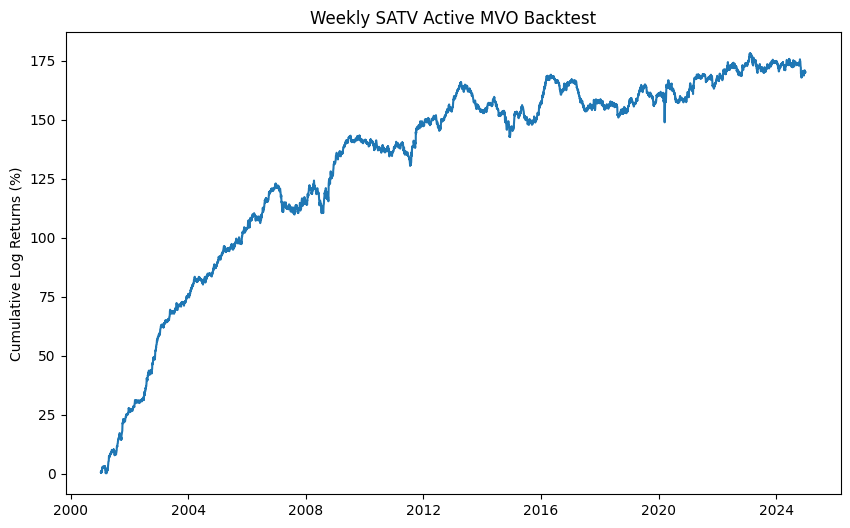

In [4]:
# Compute cumulative log returns
cumulative_returns = portfolio_returns.select(
    "date", pl.col("return").log1p().cum_sum().mul(100).alias("cumulative_return")
)

# Plot cumulative log returns
plt.figure(figsize=(10, 6))
sns.lineplot(cumulative_returns, x="date", y="cumulative_return")
plt.title("Weekly SATV Active MVO Backtest")
plt.xlabel("")
plt.ylabel("Cumulative Log Returns (%)")
plt.savefig("backtest_chart.png")

# Create summary table
summary = portfolio_returns.select(
    pl.col("return").mean().mul(252 * 100).alias("mean_return"),
    pl.col("return").std().mul(pl.lit(252).sqrt() * 100).alias("volatility"),
).with_columns(pl.col("mean_return").truediv(pl.col("volatility")).alias("sharpe"))

# Print summary
print(summary)

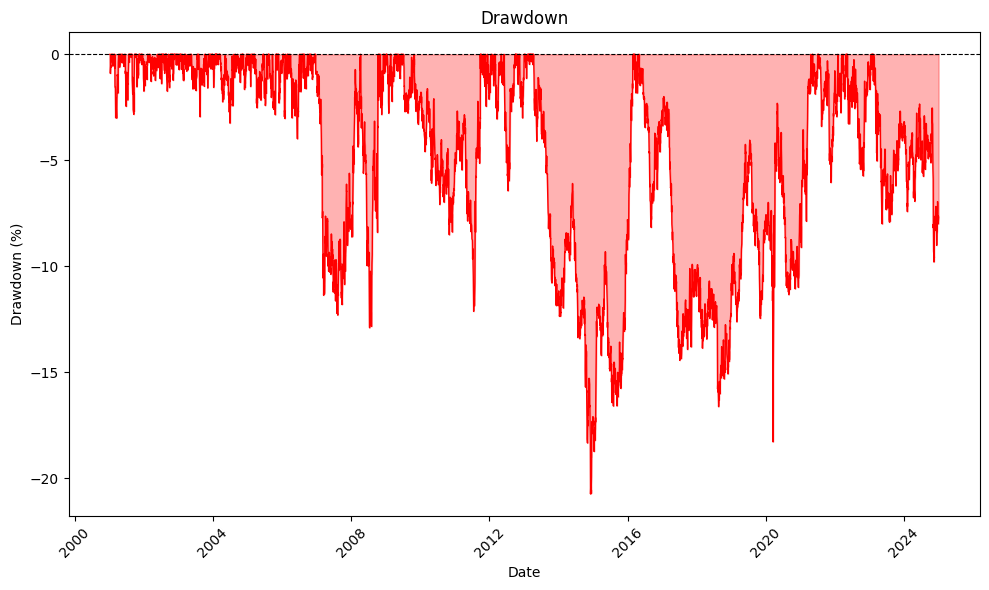

In [5]:
#create drawdown df
drawdown = (
    portfolio_returns.sort("date")
    .with_columns(pl.col("return").log1p().cum_sum().alias("_log_val"))
    .with_columns(pl.col("_log_val").cum_max().alias("_log_peak"))
    .with_columns(
        (pl.col("_log_val") - pl.col("_log_peak")).exp().sub(1).alias("drawdown")
    )
    .select("date", "drawdown")
)

#selects x and ys
x = drawdown.select("date").to_numpy().flatten()
y = drawdown.select("drawdown").to_numpy().flatten() * 100

#plot them
plt.figure(figsize=(10, 6))
plt.plot(x, y, color="red", linewidth=1)
plt.fill_between(x, y, 0, alpha=0.3, color="red")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

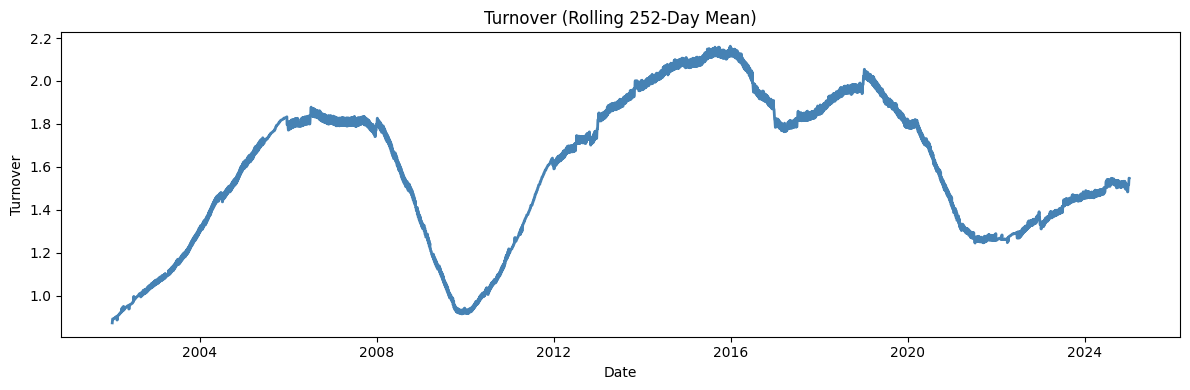

In [ ]:
#calculate and plot turnover
turnover = (
    weights
    .sort("date", "barrid")
    .with_columns(
        pl.col("weight")
        .sub(pl.col("weight").shift(1))
        .over("barrid")
        .alias("diff")
    )
    .group_by("date")
    .agg(pl.col("diff").abs().sum().alias("two_sided_turnover"))
    .sort("date")
    .with_columns(pl.col("two_sided_turnover").rolling_mean(252))
)
#plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    turnover.select("date").to_numpy().flatten(),
    turnover.select("two_sided_turnover").to_numpy().flatten(),
    color='steelblue', linewidth=2
)
ax.set_title("Turnover (Rolling 252-Day Mean)")
ax.set_xlabel("Date")
ax.set_ylabel("Turnover")
plt.tight_layout()
plt.show()

In [ ]:

#ran ff5 regression using package function
def run_ff_regression(portfolio_returns: pl.DataFrame) -> pl.DataFrame:
    """
    Run a Fama-French 5-factor regression on a single portfolio's returns.

    Regresses portfolio excess returns (return minus risk-free rate) against
    the Fama-French 5 factors using OLS. Factors are shifted by -1 day so
    that today's return is explained by yesterday's factor realizations.

    Parameters
    ----------
    portfolio_returns : pl.DataFrame
        Must contain:
        - 'date' (date): The observation date.
        - 'return' (float): Daily portfolio return.

    Returns
    -------
    pl.DataFrame
        Columns: variable (str), coefficient (float), tstat (float)
        Coefficients are annualized (x252).
    """
    start = portfolio_returns["date"].min()
    end = portfolio_returns["date"].max()

    ff5 = (
        load_fama_french(start=start, end=end)
        .sort("date")
        .with_columns(pl.exclude("date").shift(-1))
    )

    regression_data = (
        portfolio_returns.join(ff5, on="date", how="left")
        .drop_nulls("return")
        .with_columns(pl.col("return").sub(pl.col("rf")).alias("return_rf"))
        .with_columns(pl.exclude("date").mul(100))
    )

    formula = "return_rf ~ mkt_rf + smb + hml + rmw + cma"
    results = smf.ols(formula, regression_data).fit()

    return (
        pl.DataFrame(
            {
                "variable": results.params.index.tolist(),
                "coefficient": results.params.values.tolist(),
                "tstat": results.tvalues.values.tolist(),
            }
        )
        .with_columns(pl.col("coefficient").mul(252))  # annualize
    )


if __name__ == "__main__":
    import glob
    import datetime

    # --- Configure these paths ---
    WEIGHTS_DIR = "weights/satv_monthly/50"
    # -----------------------------

    files = sorted(glob.glob(f"{WEIGHTS_DIR}/[0-9][0-9][0-9][0-9].parquet"))
    weights = pl.read_parquet(files)

    # portfolio_returns = (
    #     sfp.generate_returns_from_weights(weights)
    #     .with_columns(pl.col("return").truediv(100))
    # )
    portfolio_returns = sfp.generate_returns_from_weights(weights)

    ff = run_ff_regression(portfolio_returns)
    print(ff.to_pandas().to_markdown(index=False))

| variable   |   coefficient |     tstat |
|:-----------|--------------:|----------:|
| Intercept  |     -1.71746  | -1.28931  |
| mkt_rf     |     -1.1374   | -0.945019 |
| smb        |      1.10762  |  0.491845 |
| hml        |      0.391145 |  0.191621 |
| rmw        |      1.58863  |  0.535028 |
| cma        |     -1.07872  | -0.28544  |


In [ ]:
#calculate ic using alphas created in signal creation
signal_df = pl.read_parquet("satv_weekly_alphas.parquet")
# print(signal_df.head())
# print(signal_df.columns)
signal_df = signal_df.join(returns, on=['barrid', 'date'], how='inner')

ics = sfp.generate_alpha_ics(
    signal_df.select("date", "barrid", "alpha", "fwd_return"),
    signal_df.filter(pl.col("return").is_not_null()).select("date", "barrid", "return", "fwd_return"),
)

ic_mean = ics.select(pl.col("ic").mean()).item()
ic_ir = ics.select((pl.col("ic").mean() / pl.col("ic").std()).alias("icir")).item()

print('Weekly signal IC')
print(f"IC (mean): {ic_mean:.4f}")
print(f"IC IR: {ic_ir:.3f}")

Weekly signal IC
IC (mean): 0.0066
IC IR: 0.097


In [ ]:
#testing why my leverage was high
print(weights.select("weight").describe())

print(weights.group_by("date").agg(pl.col("weight").sum()).describe())


shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ weight      │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 1.5151893e7 │
│ null_count ┆ 0.0         │
│ mean       ┆ -7.5009e-20 │
│ std        ┆ 0.003944    │
│ min        ┆ -0.036087   │
│ 25%        ┆ -0.001849   │
│ 50%        ┆ -0.000577   │
│ 75%        ┆ 0.000993    │
│ max        ┆ 0.119071    │
└────────────┴─────────────┘
shape: (9, 3)
┌────────────┬────────────────────────────┬─────────────┐
│ statistic  ┆ date                       ┆ weight      │
│ ---        ┆ ---                        ┆ ---         │
│ str        ┆ str                        ┆ f64         │
╞════════════╪════════════════════════════╪═════════════╡
│ count      ┆ 6033                       ┆ 6033.0      │
│ null_count ┆ 0                          ┆ 0.0         │
│ mean       ┆ 2013-01-04 23:09:09.577324 ┆ -4.1413e-18 │
│ std        ┆ null                       ┆ 2.1606e-16  │
│ min        ┆ 

In [ ]:
#more of the same testing
print(
    weights
    .group_by("date")
    .agg(pl.col("weight").abs().sum().alias("gross_exposure"))
    .select("gross_exposure")
    .describe()
)

shape: (9, 2)
┌────────────┬────────────────┐
│ statistic  ┆ gross_exposure │
│ ---        ┆ ---            │
│ str        ┆ f64            │
╞════════════╪════════════════╡
│ count      ┆ 6033.0         │
│ null_count ┆ 0.0            │
│ mean       ┆ 6.061203       │
│ std        ┆ 1.422864       │
│ min        ┆ 2.948686       │
│ 25%        ┆ 4.920758       │
│ 50%        ┆ 6.27435        │
│ 75%        ┆ 7.221361       │
│ max        ┆ 9.750808       │
└────────────┴────────────────┘


In [ ]:
#check long and short side separately
weights.group_by("date").agg([
    pl.col("weight").filter(pl.col("weight") > 0).sum().alias("gross_long"),
    pl.col("weight").filter(pl.col("weight") < 0).sum().alias("gross_short"),
]).describe()

statistic,date,gross_long,gross_short
str,str,f64,f64
"""count""","""6033""",6033.0,6033.0
"""null_count""","""0""",0.0,0.0
"""mean""","""2013-01-04 23:09:09.577324""",3.030601,-3.030601
"""std""",null,0.711432,0.711432
"""min""","""2001-01-08""",1.474343,-4.875404
"""25%""","""2007-01-10""",2.460379,-3.610681
"""50%""","""2013-01-07""",3.137175,-3.137175
"""75%""","""2019-01-03""",3.610681,-2.460379
"""max""","""2024-12-31""",4.875404,-1.474343
